## Quy trình biến đổi dữ liệu

 > Thứ tự áp dụng: **Numeric (scale) -> Category (encode) -> Text (TF-IDF)**

### 1) Numeric: Scale
- Với các cột lệch phải mạnh (`price`, `number_of_reviews`, `sold`):
  - Biến đổi log: $x' = \log(1 + x)$
  - Chuẩn hóa robust: $z = \frac{x' - \mathrm{median}(x')}{\mathrm{IQR}(x')}$
- Với cột có miền giá trị hữu hạn (`discount_percent`, `product_rating`):
  - Min-Max: $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$
- `freeship` là biến nhị phân 0/1 nên giữ nguyên.

### 2) Category: One-Hot Encoding
- Mã hóa mỗi giá trị category thành một vector nhị phân.

### 3) Text: TF-IDF cho `product_name`
- Tiền xử lý: lower-case, bỏ ký tự đặc biệt nhưng **giữ tiếng Việt có dấu**.
- **Không loại bỏ stopword** để giữ nguyên ngữ nghĩa cụm từ (ví dụ: `tai nghe`).
- Tính TF-IDF với unigram + bigram.

In [8]:
# import sys
# !{sys.executable} -m pip install pandas scikit-learn nltk matplotlib seaborn
# re là regular expression => dùng để loại bỏ ký tự rác
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.tokenize import word_tokenize

In [9]:
# Tải tokenizer model cho NLTK (chạy 1 lần)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

csv_path = 'clean.csv'
df = pd.read_csv(csv_path, encoding='utf-8')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (1272, 8)
Columns: ['product_name', 'price', 'discount_percent', 'product_rating', 'number_of_reviews', 'freeship', 'category', 'sold']


,product_name,price,discount_percent,product_rating,number_of_reviews,freeship,category,sold
0,điện thoại samsung galaxy a56 5g - hàng chính ...,7490000,24,5.0,19,1,điện thoại,883
1,điện thoại samsung galaxy a06 5g (4128gb) màn ...,2450000,38,4.7,16,1,điện thoại,17000
2,điện thoại tecno spark go 2 ( 4gb - 64gb) - hà...,1990000,33,5.0,1,1,điện thoại,20


In [10]:
print('So luong category duy nhat:', df['category'].nunique())
print(df['category'].value_counts().head(10))

So luong category duy nhat: 30
category
máy hút bụi            73
dưỡng da               68
camera an ninh         65
chuột máy tính         63
bàn phím               62
nồi chiên không dầu    62
tai nghe               59
mỹ phẩm                59
đồng hồ thông minh     58
laptop                 57
Name: count, dtype: int64


## Numeric: Scale

In [11]:
numeric_cols = [
    'price', 'discount_percent', 'product_rating',
    'number_of_reviews', 'freeship', 'sold'
]

df_num_scaled = df[numeric_cols].copy()

for col in numeric_cols:
    df_num_scaled[col] = pd.to_numeric(df_num_scaled[col], errors='coerce')

# Điền thiếu cho các cột số bằng median
df_num_scaled = df_num_scaled.fillna(df_num_scaled.median(numeric_only=True))

# 1) Log + RobustScaler cho các cột lệch phải
skewed_cols = ['price', 'number_of_reviews', 'sold']
for col in skewed_cols:
    df_num_scaled[col] = np.log1p(df_num_scaled[col].clip(lower=0))

robust_scaler = RobustScaler()
df_num_scaled[skewed_cols] = robust_scaler.fit_transform(df_num_scaled[skewed_cols])

# 2) Min-Max cho cột có miền giá trị hữu hạn
bounded_cols = ['discount_percent', 'product_rating']
minmax_scaler = MinMaxScaler()
df_num_scaled[bounded_cols] = minmax_scaler.fit_transform(df_num_scaled[bounded_cols])

# 3) Biến nhị phân giữ nguyên
df_num_scaled['freeship'] = (df_num_scaled['freeship'] > 0).astype(int)

print('Numeric scaled shape:', df_num_scaled.shape)
df_num_scaled.head()

Numeric scaled shape: (1272, 6)


,price,discount_percent,product_rating,number_of_reviews,freeship,sold
0,1.686208,0.328767,1.00,0.898244,1,1.458093
1,1.108530,0.520548,0.85,0.807541,1,2.610775
2,1.001030,0.452055,1.00,-0.386853,1,0.000000
3,1.360647,0.315068,1.00,0.564585,1,0.960980
4,1.476259,0.397260,1.00,1.022783,1,2.046737


## Category: One-Hot Encoding

In [12]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_matrix = ohe.fit_transform(df[['category']].fillna('other'))
cat_feature_names = ohe.get_feature_names_out(['category'])

df_ohe = pd.DataFrame(cat_matrix, columns=cat_feature_names, index=df.index)
print('Shape One-Hot:', df_ohe.shape)
df_ohe.head()

Shape One-Hot: (1272, 30)


,category_balo,category_bàn học,category_bàn phím,category_bình nước,category_bếp điện,category_camera an ninh,category_chuột máy tính,category_dưỡng da,category_ghế gaming,category_giày thể thao,...,category_nồi chiên không dầu,category_phụ kiện xe máy,category_sách kỹ năng,category_tai nghe,category_túi xách,category_áo thun,category_điện thoại,category_đồ chơi trẻ em,category_đồ gia dụng,category_đồng hồ thông minh
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## TF-IDF cho product_name

Giải thích kỹ thuật TF-IDF:
- Gọi N là số văn bản, df(t) là số văn bản chứa từ t.
- IDF: $idf(t) = log((1 + N) / (1 + df(t))) + 1$
- TF-IDF: $w(t,d) = tf(t,d) * idf(t)$
- Nếu chuẩn hóa L2: $w_norm = w / ||w||_2$
- Ý nghĩa: từ xuất hiện nhiều trong một sản phẩm nhưng ít phổ biến toàn bộ dữ liệu sẽ có trọng số cao hơn.
- Notebook này dùng `ngram_range=(1,2)` để lấy cả unigram và bigram (ví dụ: tai, tai nghe).

In [13]:
def normalize_text_vn(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text).lower().strip()
    # Giữ chữ tiếng Việt có dấu, số và khoảng trắng; loại dấu câu/ký tự đặc biệt
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def nltk_tokenizer(text: str):
    tokens = word_tokenize(text)
    return [t for t in tokens if len(t) > 1]

df['product_name_clean'] = df['product_name'].apply(normalize_text_vn)

tfidf = TfidfVectorizer(
    tokenizer=nltk_tokenizer,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=2,
    max_features=500
)

tfidf_matrix = tfidf.fit_transform(df['product_name_clean'])
tfidf_feature_names = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{c}' for c in tfidf_feature_names],
    index=df.index
)

df_encoded = pd.concat([df_num_scaled, df_ohe, df_tfidf], axis=1)

output_file = 'clean_encoded.csv'
df_encoded.to_csv(output_file, index=False, encoding='utf-8-sig')

print('Shape TF-IDF:', df_tfidf.shape)
print('Encoded shape:', df_encoded.shape)
print('Saved:', output_file)
df_encoded.head(3)

Shape TF-IDF: (1272, 500)
Encoded shape: (1272, 536)
Saved: clean_encoded.csv


,price,discount_percent,product_rating,number_of_reviews,freeship,sold,category_balo,category_bàn học,category_bàn phím,category_bình nước,...,tfidf_độ,tfidf_đội,tfidf_đội nhóm,tfidf_động,tfidf_đỡ,tfidf_đựng,tfidf_đựng mỹ,tfidf_ẩm,tfidf_ồn,tfidf_ứng
0,1.686208,0.328767,1.00,0.898244,1,1.458093,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.108530,0.520548,0.85,0.807541,1,2.610775,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.001030,0.452055,1.00,-0.386853,1,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Kiểm chứng nhanh trên 2 dòng ví dụ đầu
sample_check = pd.concat([
    df[['product_name', 'category']].head(2),
    df_ohe.head(2),
    df_tfidf.head(2).iloc[:, :10]
], axis=1)

sample_check

,product_name,category,category_balo,category_bàn học,category_bàn phím,category_bình nước,category_bếp điện,category_camera an ninh,category_chuột máy tính,category_dưỡng da,...,tfidf_10,tfidf_100,tfidf_1080p,tfidf_12,tfidf_12 tháng,tfidf_2k,tfidf_35mm,tfidf_360,tfidf_360 độ,tfidf_4g
0,điện thoại samsung galaxy a56 5g - hàng chính ...,điện thoại,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,điện thoại samsung galaxy a06 5g (4128gb) màn ...,điện thoại,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Trực quan hóa: so sánh `clean.csv` và `clean_encoded.csv`

Mục tiêu:
- So sánh kích thước dữ liệu trước/sau encode.
- So sánh phân phối biến số trước (raw) và sau khi scale.
- Ước lượng độ thưa (sparsity) của ma trận encoded.

,dataset,rows,columns
0,clean.csv,1272,8
1,clean_encoded.csv,1272,536


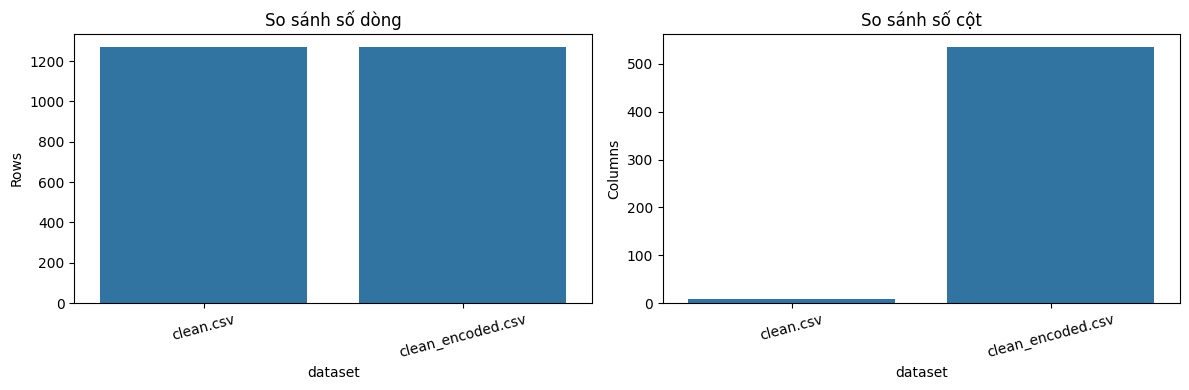

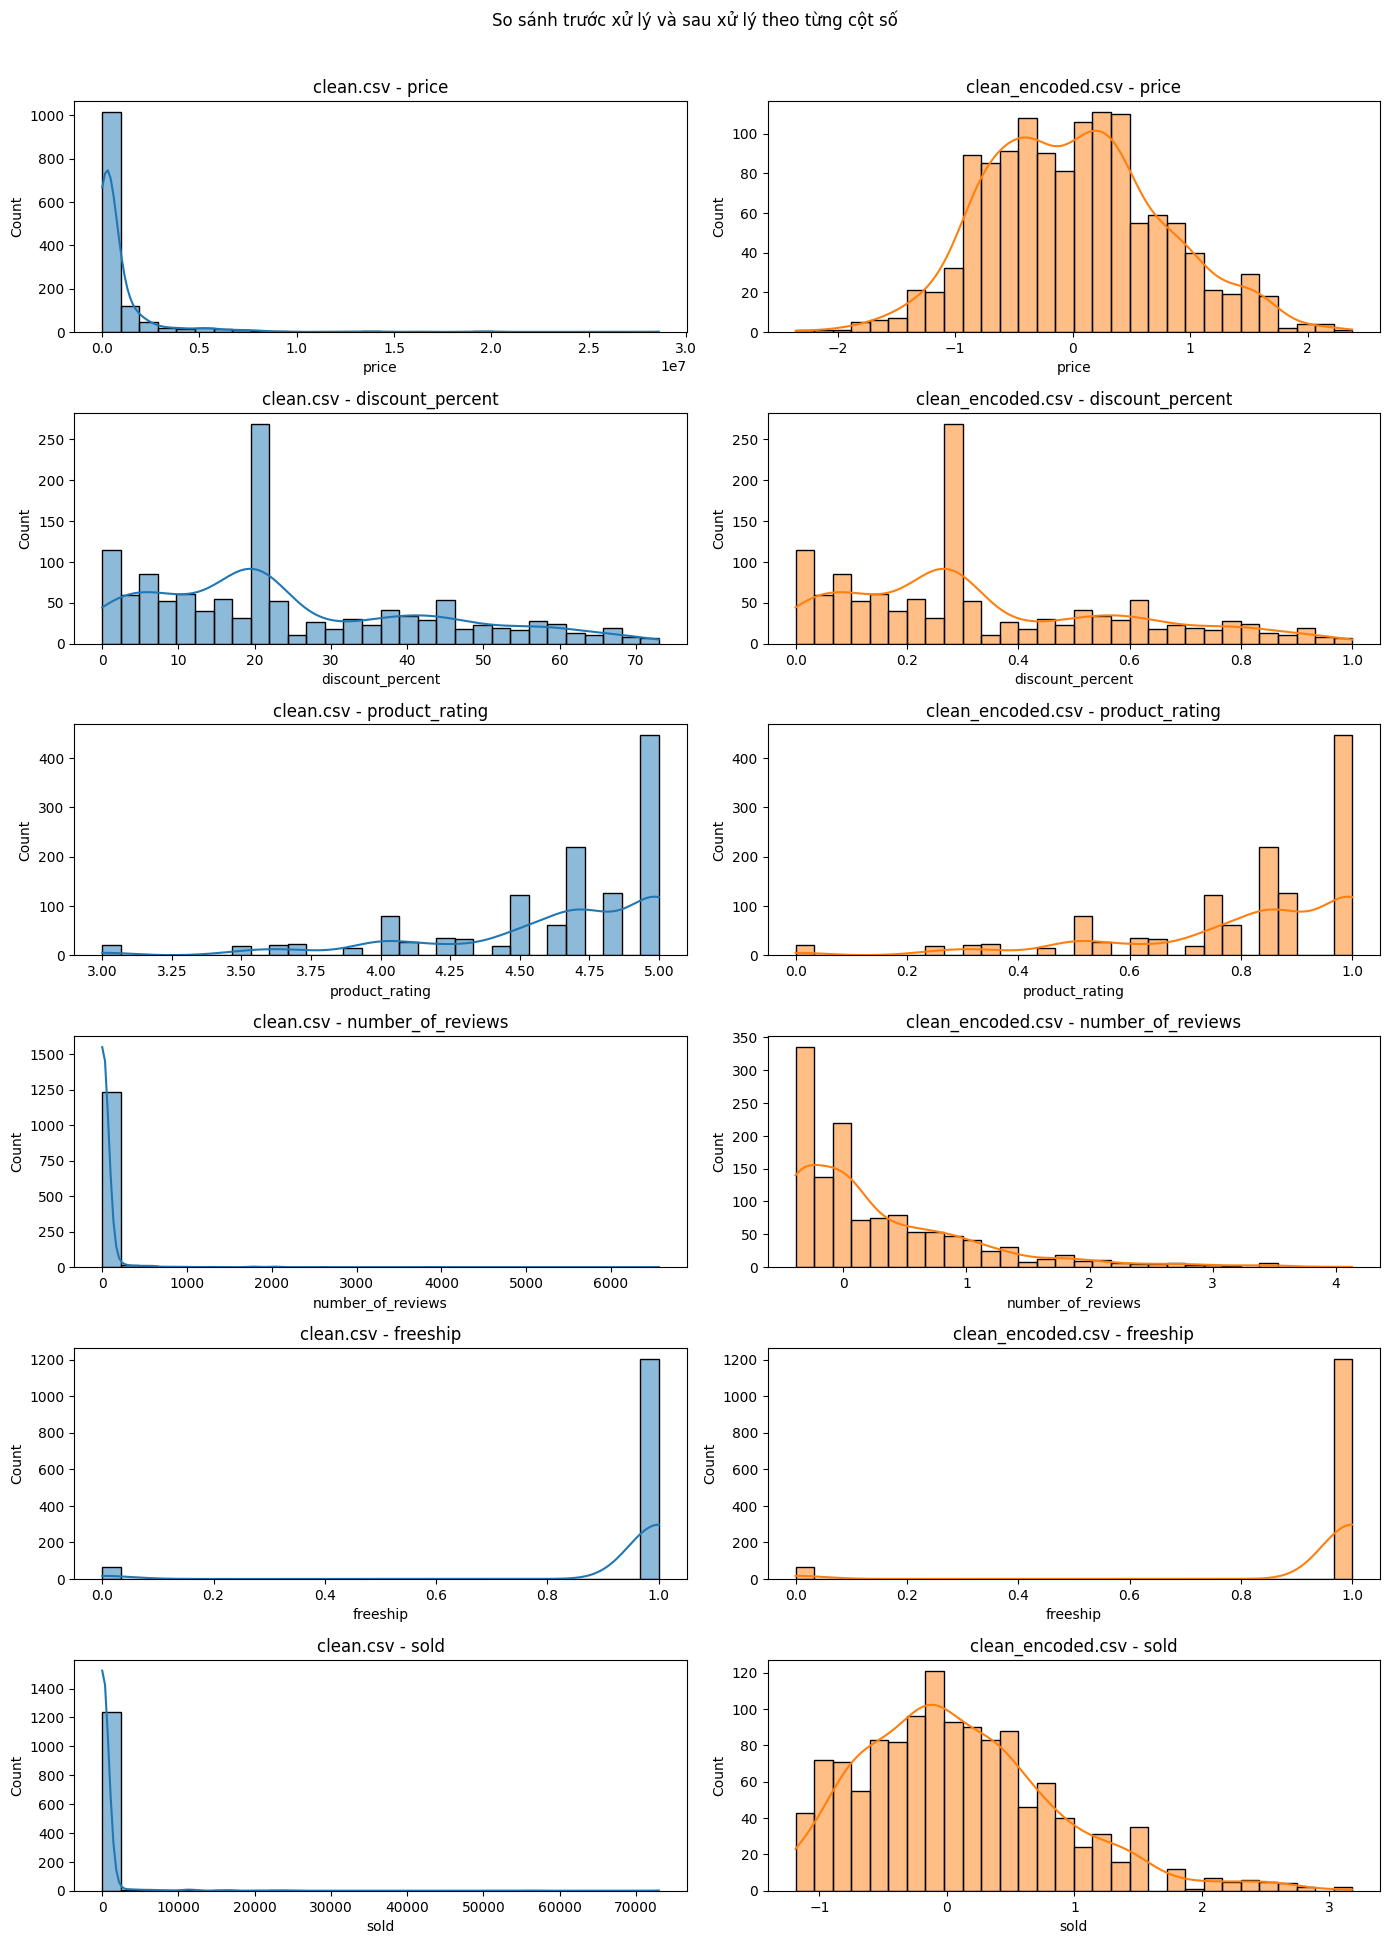

Non-zero values: 27,655
Total values   : 681,792
Sparsity       : 0.9594 (95.94%)


In [ ]:
df_raw = pd.read_csv('clean.csv', encoding='utf-8')
df_enc = pd.read_csv('clean_encoded.csv', encoding='utf-8')

numeric_compare_cols = ['price', 'discount_percent', 'product_rating', 'number_of_reviews', 'freeship', 'sold']

# 1) So sánh shape
shape_compare = pd.DataFrame({
    'dataset': ['clean.csv', 'clean_encoded.csv'],
    'rows': [df_raw.shape[0], df_enc.shape[0]],
    'columns': [df_raw.shape[1], df_enc.shape[1]]
})
display(shape_compare)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=shape_compare, x='dataset', y='rows', ax=axes[0])
axes[0].set_title('So sánh số dòng')
axes[0].set_ylabel('Rows')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=shape_compare, x='dataset', y='columns', ax=axes[1])
axes[1].set_title('So sánh số cột')
axes[1].set_ylabel('Columns')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 2) So sánh trực tiếp trước/sau theo từng cột số (trái: clean.csv, phải: clean_encoded.csv)
fig, axes = plt.subplots(len(numeric_compare_cols), 2, figsize=(14, 3.2 * len(numeric_compare_cols)))

for i, col in enumerate(numeric_compare_cols):
    left_ax = axes[i, 0]
    right_ax = axes[i, 1]

    sns.histplot(df_raw[col].dropna(), bins=30, kde=True, ax=left_ax, color='#1f77b4')
    left_ax.set_title(f'clean.csv - {col}')
    left_ax.set_xlabel(col)
    left_ax.set_ylabel('Count')

    sns.histplot(df_enc[col].dropna(), bins=30, kde=True, ax=right_ax, color='#ff7f0e')
    right_ax.set_title(f'clean_encoded.csv - {col}')
    right_ax.set_xlabel(col)
    right_ax.set_ylabel('Count')

plt.suptitle('So sánh trước xử lý và sau xử lý: ', y=1.01)
plt.tight_layout()
plt.show()

# 3) Độ thưa của dữ liệu encoded
non_zero = (df_enc != 0).sum().sum()
total_values = df_enc.shape[0] * df_enc.shape[1]
sparsity = 1 - (non_zero / total_values)

print(f'Non-zero values: {non_zero:,}')
print(f'Total values   : {total_values:,}')
print(f'Sparsity       : {sparsity:.4f} ({sparsity*100:.2f}%)')